# Class-conditional lens-image generation with a DDPM

This tutorial adds discrete class conditioning to a DDPM (PLAN.md item A1). It trains on real ML4SCI DeepLense substructure-classification images: three class folders (`no`, `sphere`, `vort`: no-substructure, CDM, and axion) of single-channel `.npy` lens images, each with its own train/val split. The original dataset's Google Drive links are dead, so this downloads a verified Hugging Face re-upload, `nelm/gsoc-2026-deeplense-dataset`, on first run.

The class-defining substructure is a subtle, localized perturbation rather than a distinct global pattern. A 100-step schedule and 20 epochs (enough for the earlier synthetic stand-in, where each class was a visually distinct global pattern) collapsed here: the model ignored the class label and the classifier scored at chance. A 1000-step noise schedule (the standard DDPM schedule, and this library's own default in `astrogen/tasks/*.py`) and 100 epochs recover real per-class separation.

## What you will do

1. Download and load labeled DeepLense substructure images.
2. Train an evaluation classifier that can actually separate the three classes.
3. Train a class-conditional DDPM and measure conditional accuracy.


In [1]:
from pathlib import Path
import sys
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from diffusers import DDPMScheduler, UNet2DModel
from huggingface_hub import hf_hub_download
from sklearn.metrics import f1_score
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm

sys.path.insert(0, str(Path.cwd().parent))
from astrogen.models import DDPM
from examples.evaluation.classifiers import ImageClassifier

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DATA_ROOT = Path.cwd().parent / "data" / "deeplense"
REPO_ID = "nelm/gsoc-2026-deeplense-dataset"
CLASS_FOLDERS = ["no", "vort", "sphere"]
CLASS_NAMES = ["no_sub", "axion", "cdm"]
NUM_CLASSES = len(CLASS_FOLDERS)
IMAGE_SIZE = 64
torch.manual_seed(0)
print(f"Using {DEVICE}")


Could not find the bitsandbytes CUDA binary at PosixPath('/home/mi3se/.conda/envs/astroclip/lib/python3.10/site-packages/bitsandbytes/libbitsandbytes_cuda128.so')


The installed version of bitsandbytes was compiled without GPU support. 8-bit optimizers, 8-bit multiplication, and GPU quantization are unavailable.


Using cuda


## Download and load labeled DeepLense images

Each `.npy` file is a single-channel 150x150 lens image already scaled to `[0, 1]`. `_extract_subset` pulls only the `.npy` members this run needs out of the archive (not the full 6.5 GB dataset), caching them under `data/deeplense`. Substructure is a subtle, localized perturbation, so images are downsampled only to `IMAGE_SIZE=64` (not smaller) and rescaled to `[-1, 1]` for the diffusion model.


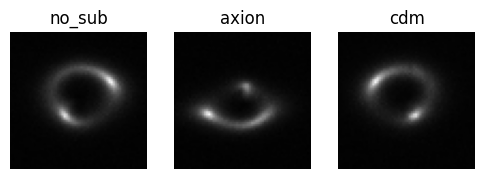

In [2]:
def _extract_subset(cache_dir: Path, split: str, count_per_class: int) -> None:
    zip_path = hf_hub_download(REPO_ID, "dataset.zip", repo_type="dataset")
    with zipfile.ZipFile(zip_path) as archive:
        members = []
        for folder in CLASS_FOLDERS:
            existing_dir = cache_dir / "dataset" / split / folder
            existing = len(list(existing_dir.glob("*.npy"))) if existing_dir.exists() else 0
            if existing >= count_per_class:
                continue
            prefix = f"dataset/{split}/{folder}/"
            members += sorted(n for n in archive.namelist() if n.startswith(prefix) and n.endswith(".npy"))[:count_per_class]
        if members:
            archive.extractall(cache_dir, members=members)

def load_split(split: str, count_per_class: int) -> tuple[torch.Tensor, torch.Tensor]:
    _extract_subset(DATA_ROOT, split, count_per_class)
    images, labels = [], []
    for class_index, folder in enumerate(CLASS_FOLDERS):
        files = sorted((DATA_ROOT / "dataset" / split / folder).glob("*.npy"))[:count_per_class]
        batch = torch.from_numpy(np.stack([np.load(f) for f in files])).float()
        images.append(batch)
        labels.append(torch.full((len(files),), class_index))
    images = F.interpolate(torch.cat(images), size=IMAGE_SIZE, mode="bilinear")
    return (images * 2 - 1).clamp(-1, 1), torch.cat(labels)

train_images, train_labels = load_split("train", count_per_class=10000)
val_images, val_labels = load_split("val", count_per_class=2500)

_, axes = plt.subplots(1, NUM_CLASSES, figsize=(6, 2))
for class_index, axis in enumerate(axes):
    axis.imshow(train_images[train_labels == class_index][0, 0], cmap="gray", vmin=-1, vmax=1)
    axis.set_title(CLASS_NAMES[class_index])
    axis.axis("off")
plt.show()


## Train an evaluation classifier

The classifier is deliberately separate from the generator. Its accuracy on generated images is a task-relevant diagnostic: high accuracy means the requested label remains recognizable in samples.

In [3]:
classifier = ImageClassifier(num_classes=NUM_CLASSES).to(DEVICE)
classifier_optimizer = torch.optim.Adam(classifier.parameters(), lr=1e-3)
classifier_loader = DataLoader(TensorDataset(train_images, train_labels), batch_size=128, shuffle=True)

classifier.train()
progress = tqdm(range(30), desc="classifier")
for _ in progress:
    for batch_images, batch_labels in classifier_loader:
        classifier_optimizer.zero_grad()
        loss = torch.nn.functional.cross_entropy(
            classifier(batch_images.to(DEVICE)), batch_labels.to(DEVICE)
        )
        loss.backward()
        classifier_optimizer.step()
    classifier.eval()
    with torch.no_grad():
        val_accuracy = (
            classifier(val_images.to(DEVICE)).argmax(dim=-1) == val_labels.to(DEVICE)
        ).float().mean().item()
    classifier.train()
    progress.set_postfix(train_loss=f"{loss.item():.4f}", val_accuracy=f"{val_accuracy:.2%}")


classifier:   0%|          | 0/30 [00:00<?, ?it/s]

## Build and train the conditional DDPM

`num_class_embeds` creates class embeddings in diffusers' U-Net. Passing `labels` to AstroGen's `DDPM` supplies those embeddings during both training and sampling.

In [4]:
unet = UNet2DModel(
    in_channels=1,
    out_channels=1,
    layers_per_block=1,
    block_out_channels=(32, 64, 128),
    down_block_types=("DownBlock2D",) * 3,
    up_block_types=("UpBlock2D",) * 3,
    norm_num_groups=32,
    num_class_embeds=NUM_CLASSES,
)
model = DDPM(unet, DDPMScheduler(num_train_timesteps=1000)).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=2e-4)
loader = DataLoader(TensorDataset(train_images, train_labels), batch_size=128, shuffle=True)

progress = tqdm(range(100), desc="DDPM")
for _ in progress:
    model.train()
    for batch_images, batch_labels in loader:
        optimizer.zero_grad()
        loss = model(batch_images.to(DEVICE), labels=batch_labels.to(DEVICE))
        loss.backward()
        optimizer.step()
    model.eval()
    with torch.no_grad():
        val_loss = model(val_images.to(DEVICE), labels=val_labels.to(DEVICE)).item()
    progress.set_postfix(train_loss=f"{loss.item():.4f}", val_loss=f"{val_loss:.4f}")


DDPM:   0%|          | 0/100 [00:00<?, ?it/s]

## Sample each requested class and score it

The generated grid is grouped by conditioning label. Overall accuracy and macro F1 compare the requested label with the classifier prediction; per-class accuracy and F1 show whether any single class is harder to condition on.


classifier accuracy on generated samples (192 total): 60.42%
macro F1: 58.14%
class no_sub: accuracy=95.31%, f1=74.39%
class axion: accuracy=42.19%, f1=50.47%
class cdm: accuracy=43.75%, f1=49.56%


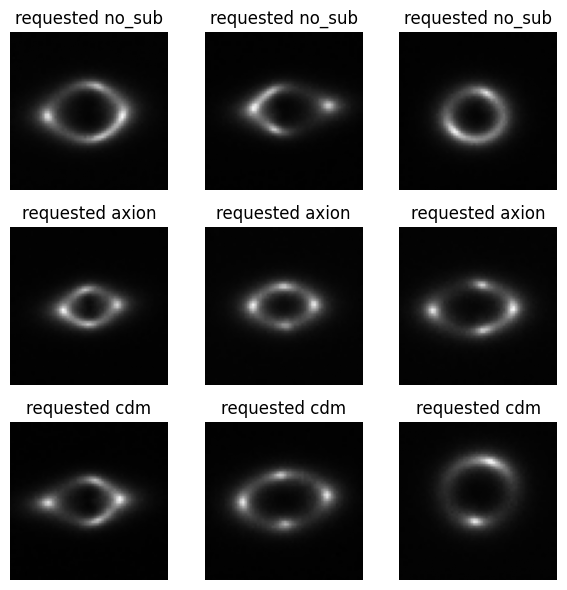

In [5]:
model.eval()
classifier.eval()
SAMPLES_PER_CLASS_EVAL = 64
VISUALIZE_PER_CLASS = 3
conditioning_labels = torch.arange(NUM_CLASSES).repeat_interleave(SAMPLES_PER_CLASS_EVAL).to(DEVICE)
with torch.no_grad():
    samples = model.sample(count=len(conditioning_labels), sample_size=IMAGE_SIZE, labels=conditioning_labels)
    predicted_labels = classifier(samples).argmax(dim=-1)
requested = conditioning_labels.cpu()
predicted = predicted_labels.cpu()
accuracy = (predicted == requested).float().mean().item()
macro_f1 = f1_score(requested, predicted, average="macro", labels=range(NUM_CLASSES), zero_division=0)
per_class_f1 = f1_score(requested, predicted, average=None, labels=range(NUM_CLASSES), zero_division=0)
print(f"classifier accuracy on generated samples ({len(requested)} total): {accuracy:.2%}")
print(f"macro F1: {macro_f1:.2%}")
for class_index in range(NUM_CLASSES):
    class_mask = requested == class_index
    class_accuracy = (predicted[class_mask] == requested[class_mask]).float().mean().item()
    print(f"class {CLASS_NAMES[class_index]}: accuracy={class_accuracy:.2%}, f1={per_class_f1[class_index]:.2%}")

visualize_indices = [
    class_index * SAMPLES_PER_CLASS_EVAL + offset
    for class_index in range(NUM_CLASSES)
    for offset in range(VISUALIZE_PER_CLASS)
]
_, axes = plt.subplots(NUM_CLASSES, VISUALIZE_PER_CLASS, figsize=(6, 6))
for axis, sample_index in zip(axes.flat, visualize_indices):
    axis.imshow(samples[sample_index, 0].cpu(), cmap="gray", vmin=-1, vmax=1)
    axis.set_title(f"requested {CLASS_NAMES[conditioning_labels[sample_index].item()]}")
    axis.axis("off")
plt.tight_layout()
plt.show()
